# Analyse map-first des agents Valorant

Objectif : ne plus limiter l'analyse aux 10 agents les plus joués globalement.  
Ce notebook analyse chaque carte indépendamment afin de détecter :

- les agents dominants par map ;
- les agents joués uniquement dans certains contextes ;
- les absences anormales ;
- les cartes très standardisées ou au contraire ouvertes ;
- les agents spécialistes de map ;
- les hypothèses d'interprétation stratégique.

> Limite importante : avec ce fichier, on observe uniquement des picks et des pick rates. On peut détecter des patterns, mais pas prouver causalement pourquoi un agent est fort ou absent. Les explications produites sont donc des hypothèses à valider avec de la connaissance jeu, VOD ou données de compositions complètes.


In [6]:
# ============================================================
# 1. Imports et configuration
# ============================================================

from pathlib import Path
import math
import textwrap

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 300)
pd.set_option('display.width', 160)

DATA_PATH = Path('data/processed/vlr_agents_matrix_aggregated.csv')

# Si tu exécutes le notebook ailleurs, adapte le chemin :
# DATA_PATH = Path('/mnt/data/vlr_agents_matrix_aggregated.csv')


In [8]:
# ============================================================
# 2. Chargement et contrôle qualité minimal
# ============================================================

if not DATA_PATH.exists():
    fallback = Path('/mnt/data/vlr_agents_matrix_aggregated.csv')
    if fallback.exists():
        DATA_PATH = fallback
    else:
        raise FileNotFoundError(f'Fichier introuvable : {DATA_PATH}')

raw = pd.read_csv(DATA_PATH)

required_cols = {'map', 'agent', 'agent_picks', 'total_compositions', 'pick_rate'}
missing = required_cols - set(raw.columns)
if missing:
    raise ValueError(f'Colonnes manquantes : {missing}')

# Normalisation légère
raw = raw.copy()
raw['map'] = raw['map'].astype(str).str.strip()
raw['agent'] = raw['agent'].astype(str).str.strip().str.lower()
raw['agent_picks'] = pd.to_numeric(raw['agent_picks'], errors='coerce').fillna(0).astype(int)
raw['total_compositions'] = pd.to_numeric(raw['total_compositions'], errors='coerce')
raw['pick_rate'] = pd.to_numeric(raw['pick_rate'], errors='coerce')

print('Shape:', raw.shape)
display(raw.head(10))
display(raw.groupby('map').agg(nb_agents_observed=('agent', 'nunique'), total_compositions=('total_compositions', 'max')).sort_index())


Shape: (156, 5)


,map,agent,agent_picks,total_compositions,pick_rate
0,All Maps,neon,372,460,0.81
1,All Maps,omen,233,460,0.51
2,All Maps,viper,230,460,0.50
3,All Maps,fade,164,460,0.36
4,All Maps,waylay,167,460,0.36
5,All Maps,skye,155,460,0.34
6,All Maps,astra,115,460,0.25
7,All Maps,sova,111,460,0.24
8,All Maps,brimstone,104,460,0.23
9,All Maps,cypher,106,460,0.23


,nb_agents_observed,total_compositions
map,,
All Maps,27,460
BIND,20,60
BREEZE,16,48
FRACTURE,20,54
HAVEN,18,76
LOTUS,20,90
PEARL,18,64
SPLIT,17,68


## 3. Pourquoi l'ancien top 10 global est insuffisant

Un agent peut être excellent sur une carte précise mais peu visible globalement s'il est :

- très fort sur une ou deux maps seulement ;
- joué dans des compositions spécifiques ;
- dépendant d'une stratégie d'équipe ;
- remplacé par un agent plus flexible sur les autres cartes.

Donc on reconstruit une matrice complète `map × agent`, y compris les agents à 0 % sur certaines maps. C'est indispensable pour analyser les absences.


In [10]:
# ============================================================
# 3. Construction d'une matrice complète map × agent
# ============================================================

all_maps_row = raw[raw['map'].str.lower().eq('all maps')].copy()
map_df = raw[~raw['map'].str.lower().eq('all maps')].copy()

maps = sorted(map_df['map'].unique())
agents = sorted(raw['agent'].unique())

# Total de compositions par map
map_totals = map_df.groupby('map')['total_compositions'].max().rename('map_total_compositions')

# Matrice complète pour inclure les agents jamais joués sur une map
full_index = pd.MultiIndex.from_product([maps, agents], names=['map', 'agent'])
full = (
    map_df.set_index(['map', 'agent'])[['agent_picks', 'pick_rate']]
    .reindex(full_index)
    .reset_index()
)

full = full.merge(map_totals, on='map', how='left')
full['agent_picks'] = full['agent_picks'].fillna(0).astype(int)
full['pick_rate'] = full['pick_rate'].fillna(0.0)
full['map_total_compositions'] = full['map_total_compositions'].fillna(0).astype(int)

# Stats globales par agent issues de All Maps si disponible
if not all_maps_row.empty:
    global_stats = all_maps_row[['agent', 'agent_picks', 'total_compositions', 'pick_rate']].rename(columns={
        'agent_picks': 'global_picks',
        'total_compositions': 'global_total_compositions',
        'pick_rate': 'global_pick_rate',
    })
else:
    # fallback si All Maps n'existe pas
    global_stats = (
        full.groupby('agent', as_index=False)
        .agg(global_picks=('agent_picks', 'sum'), global_total_compositions=('map_total_compositions', 'sum'))
    )
    global_stats['global_pick_rate'] = global_stats['global_picks'] / global_stats['global_total_compositions'].replace(0, np.nan)

full = full.merge(global_stats, on='agent', how='left')
full['global_pick_rate'] = full['global_pick_rate'].fillna(0.0)
full['global_picks'] = full['global_picks'].fillna(0).astype(int)

# Rang intra-map : beaucoup plus utile que le rang global
full['map_rank'] = full.groupby('map')['pick_rate'].rank(method='dense', ascending=False).astype(int)
full['pick_rate_gap_vs_global'] = full['pick_rate'] - full['global_pick_rate']
full['pick_rate_ratio_vs_global'] = np.where(full['global_pick_rate'] > 0, full['pick_rate'] / full['global_pick_rate'], np.nan)

# Catégorisation simple, configurable
conditions = [
    full['pick_rate'].ge(0.50),
    full['pick_rate'].ge(0.30),
    full['pick_rate'].ge(0.15),
    full['pick_rate'].gt(0),
]
labels = ['core pick', 'strong pick', 'situational pick', 'rare pick']
full['map_pick_tier'] = np.select(conditions, labels, default='not picked')

print('Matrice complète:', full.shape)
display(full.sort_values(['map', 'map_rank', 'agent']).head(30))


Matrice complète: (189, 12)


,map,agent,agent_picks,pick_rate,map_total_compositions,global_picks,global_total_compositions,global_pick_rate,map_rank,pick_rate_gap_vs_global,pick_rate_ratio_vs_global,map_pick_tier
2,BIND,brimstone,56,0.93,60,104,460,0.23,1,0.70,4.043478,core pick
19,BIND,skye,54,0.90,60,155,460,0.34,2,0.56,2.647059,core pick
23,BIND,viper,54,0.90,60,230,460,0.50,2,0.40,1.800000,core pick
14,BIND,neon,53,0.88,60,372,460,0.81,3,0.07,1.086420,core pick
25,BIND,waylay,37,0.62,60,167,460,0.36,4,0.26,1.722222,core pick
3,BIND,chamber,8,0.13,60,58,460,0.13,5,0.00,1.000000,rare pick
17,BIND,raze,6,0.10,60,80,460,0.17,6,-0.07,0.588235,rare pick
16,BIND,phoenix,5,0.08,60,70,460,0.15,7,-0.07,0.533333,rare pick
0,BIND,astra,4,0.07,60,115,460,0.25,8,-0.18,0.280000,rare pick
6,BIND,fade,4,0.07,60,164,460,0.36,8,-0.29,0.194444,rare pick


## 4. Vue complète : heatmap de tous les agents par carte

Cette heatmap est volontairement large : elle évite de masquer les agents non top 10 globalement.


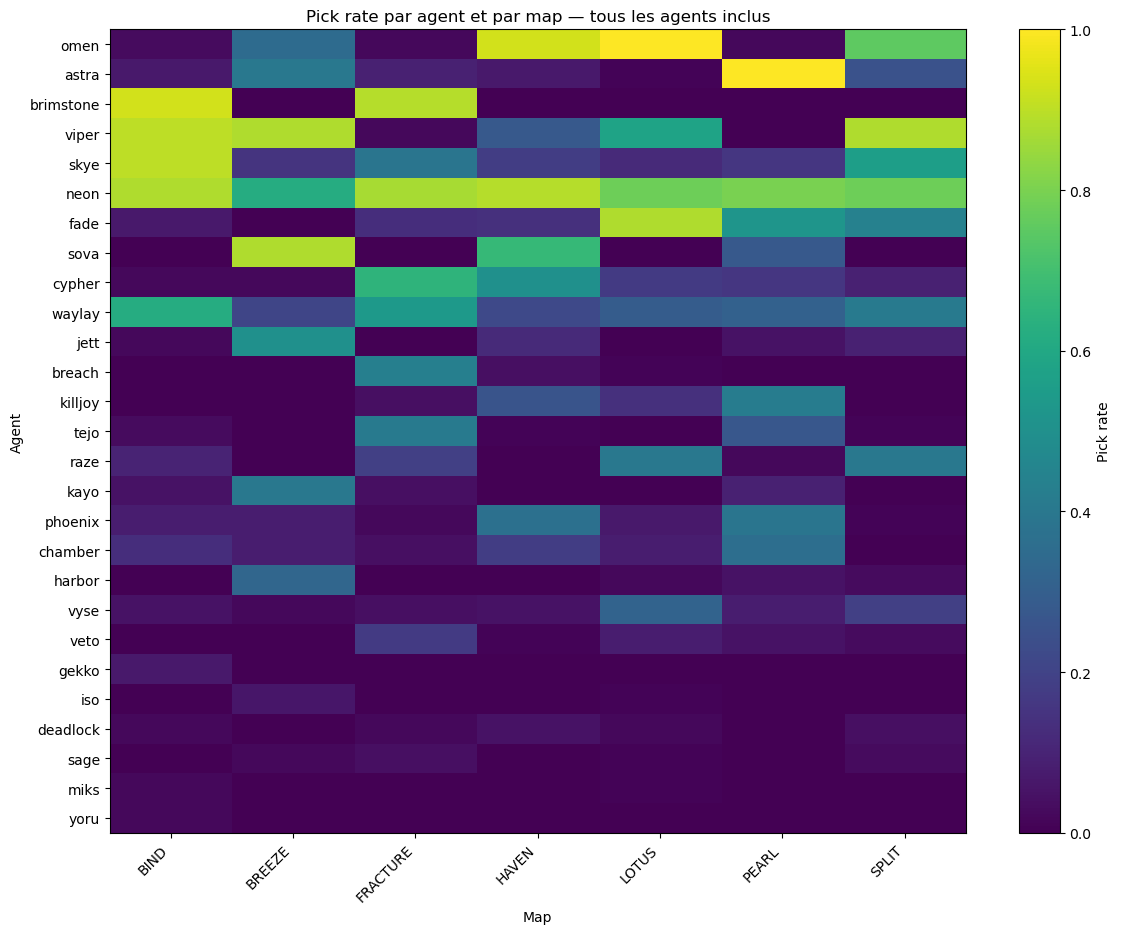

In [12]:
# ============================================================
# 4. Heatmap complète agents × maps
# ============================================================

pivot = full.pivot(index='agent', columns='map', values='pick_rate').fillna(0)

# Tri : agents les plus structurants en haut, mais sans supprimer les autres
agent_order = (
    full.groupby('agent')
    .agg(max_pick_rate=('pick_rate', 'max'), mean_pick_rate=('pick_rate', 'mean'), global_pick_rate=('global_pick_rate', 'max'))
    .sort_values(['max_pick_rate', 'global_pick_rate', 'mean_pick_rate'], ascending=False)
    .index
)
pivot = pivot.loc[agent_order]

fig_height = max(8, 0.35 * len(pivot))
plt.figure(figsize=(12, fig_height))
plt.imshow(pivot.values, aspect='auto')
plt.xticks(range(len(pivot.columns)), pivot.columns, rotation=45, ha='right')
plt.yticks(range(len(pivot.index)), pivot.index)
plt.colorbar(label='Pick rate')
plt.title('Pick rate par agent et par map — tous les agents inclus')
plt.xlabel('Map')
plt.ylabel('Agent')
plt.tight_layout()
plt.show()


## 5. Analyse indépendante de chaque carte

Ici, on ne prend pas les meilleurs agents du jeu. On prend les agents qui structurent **chaque map**.


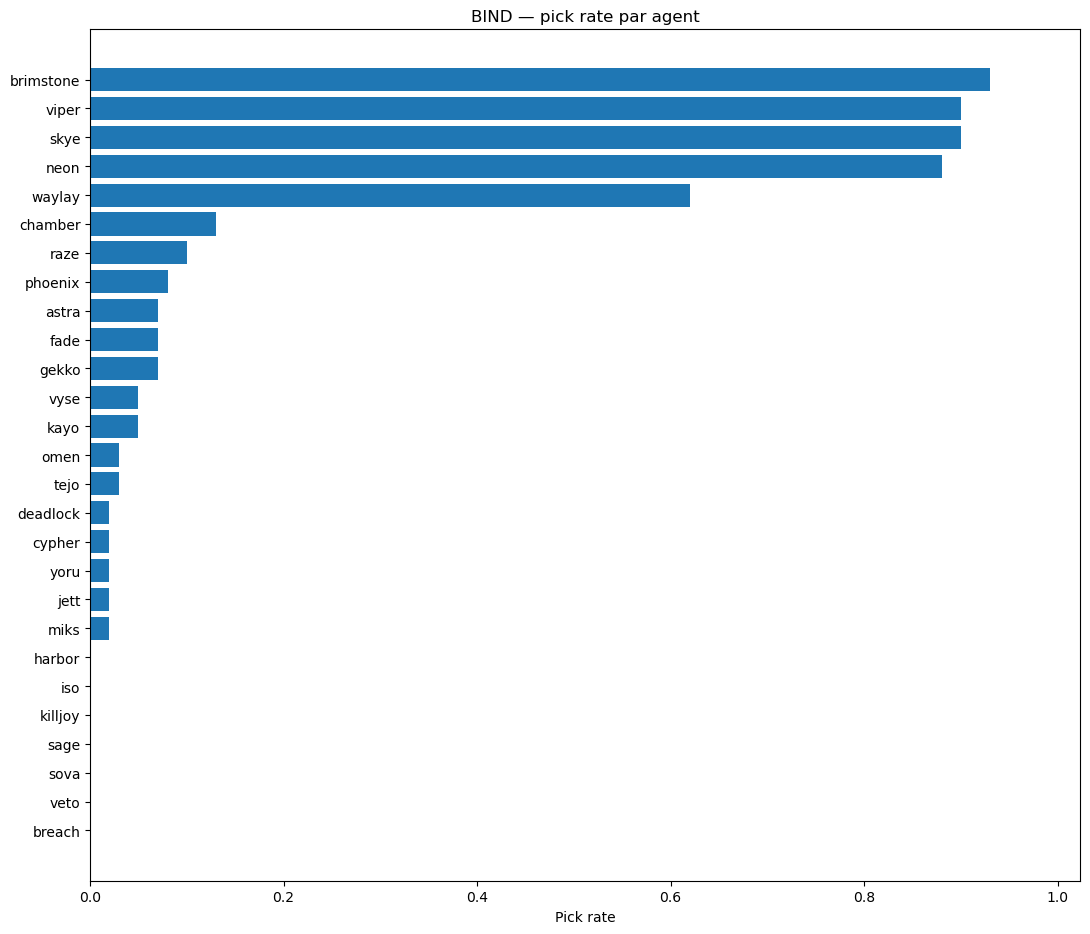

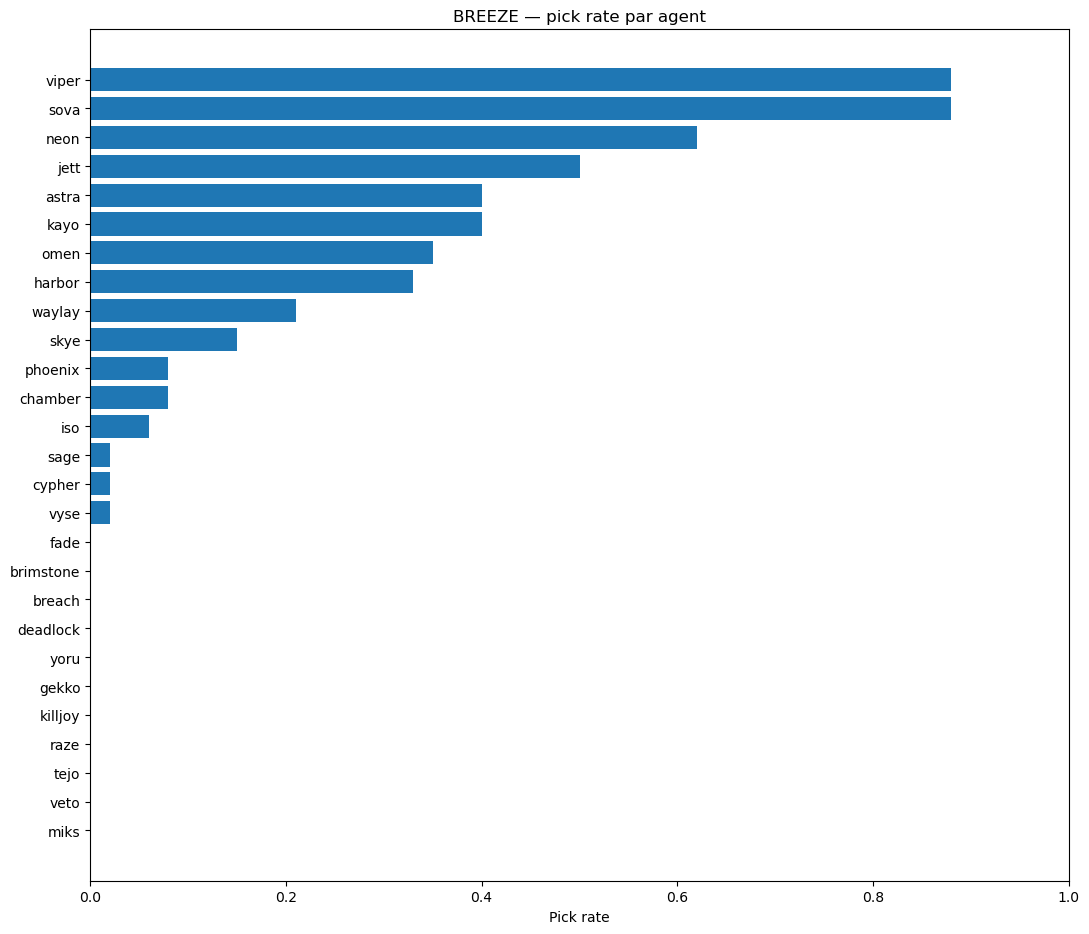

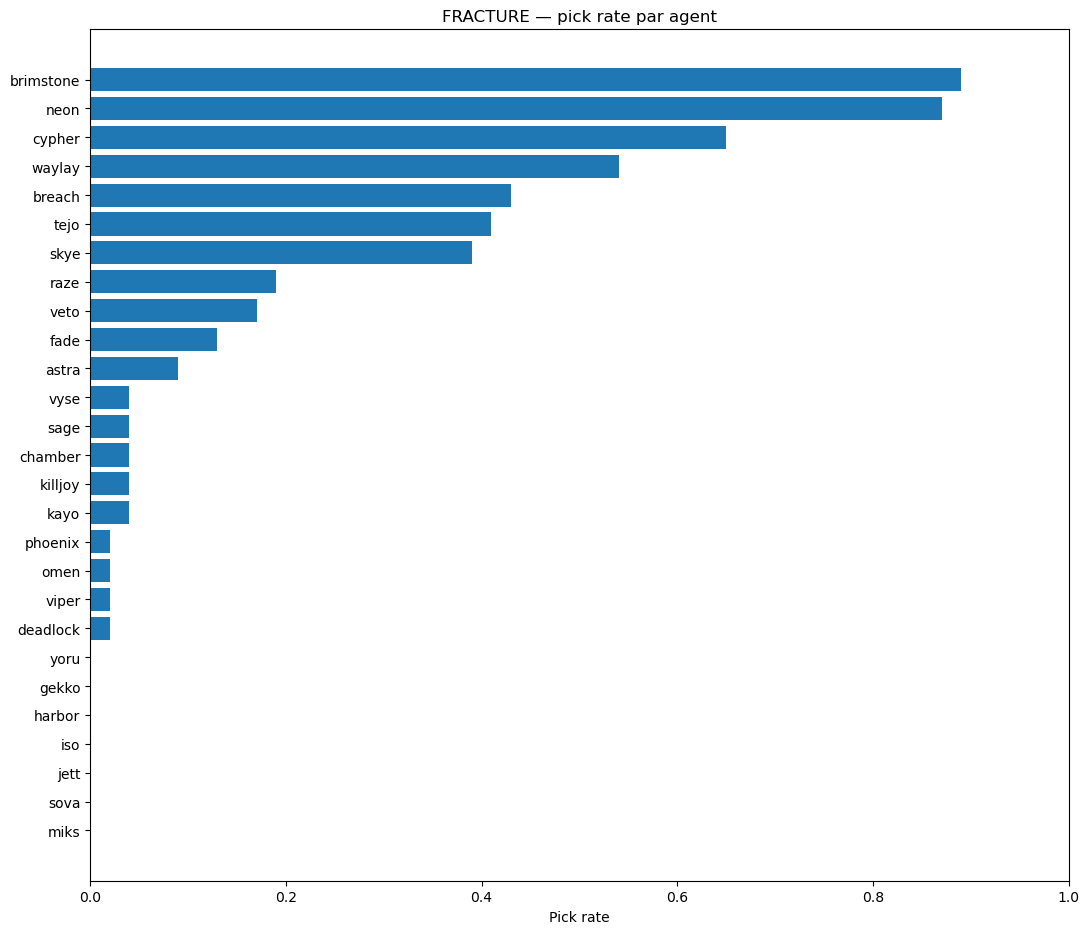

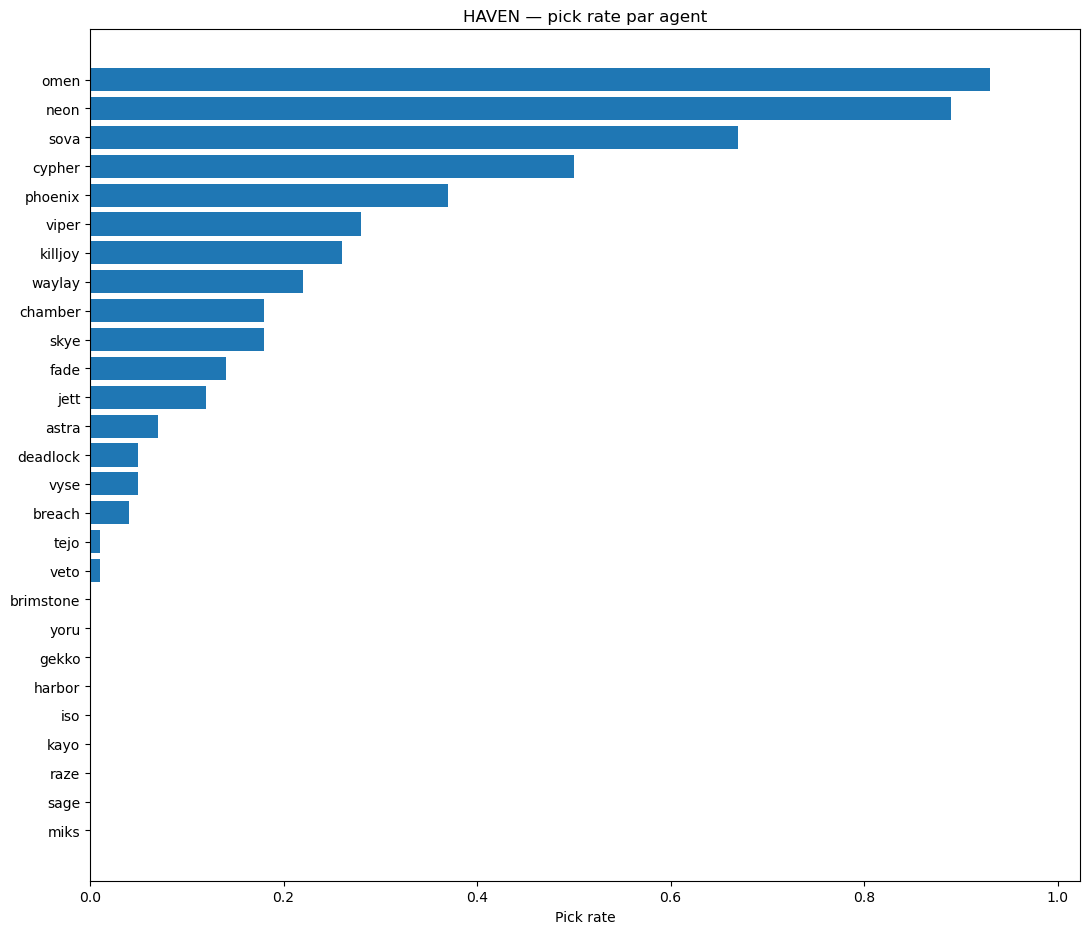

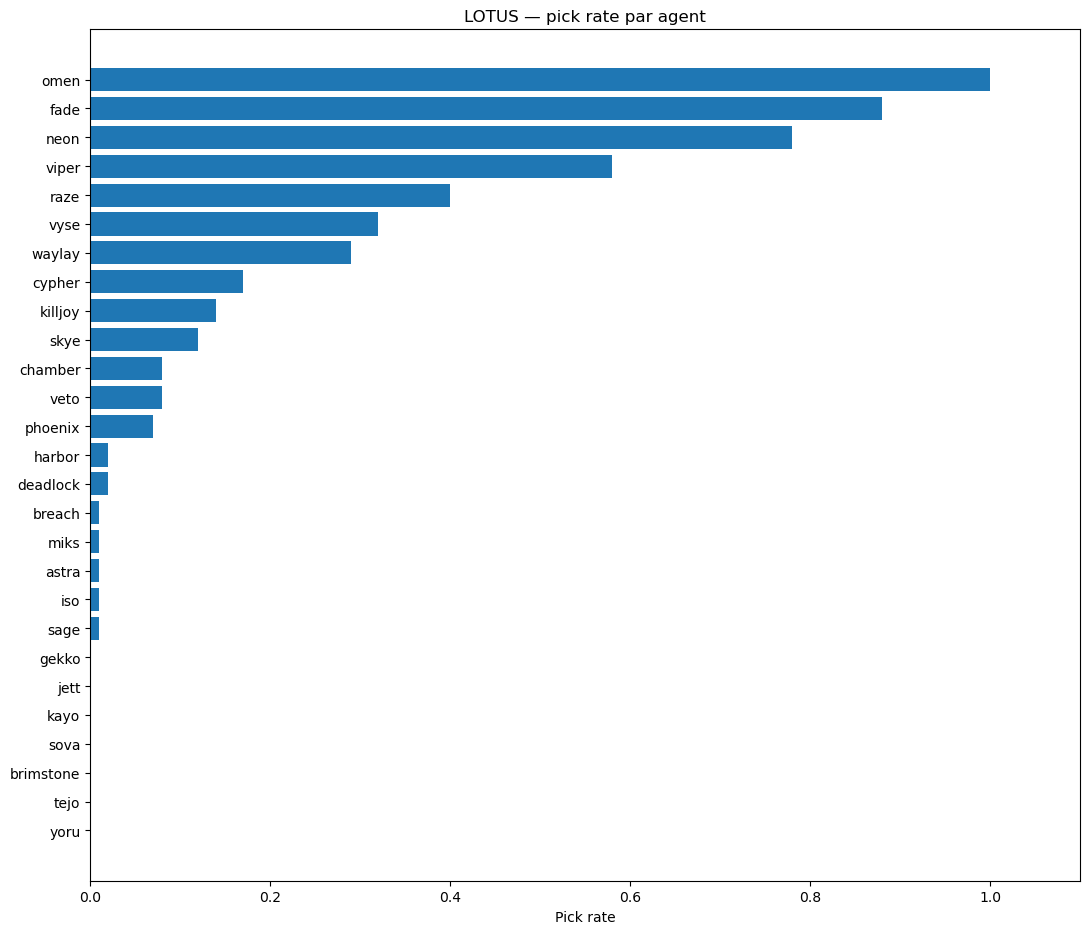

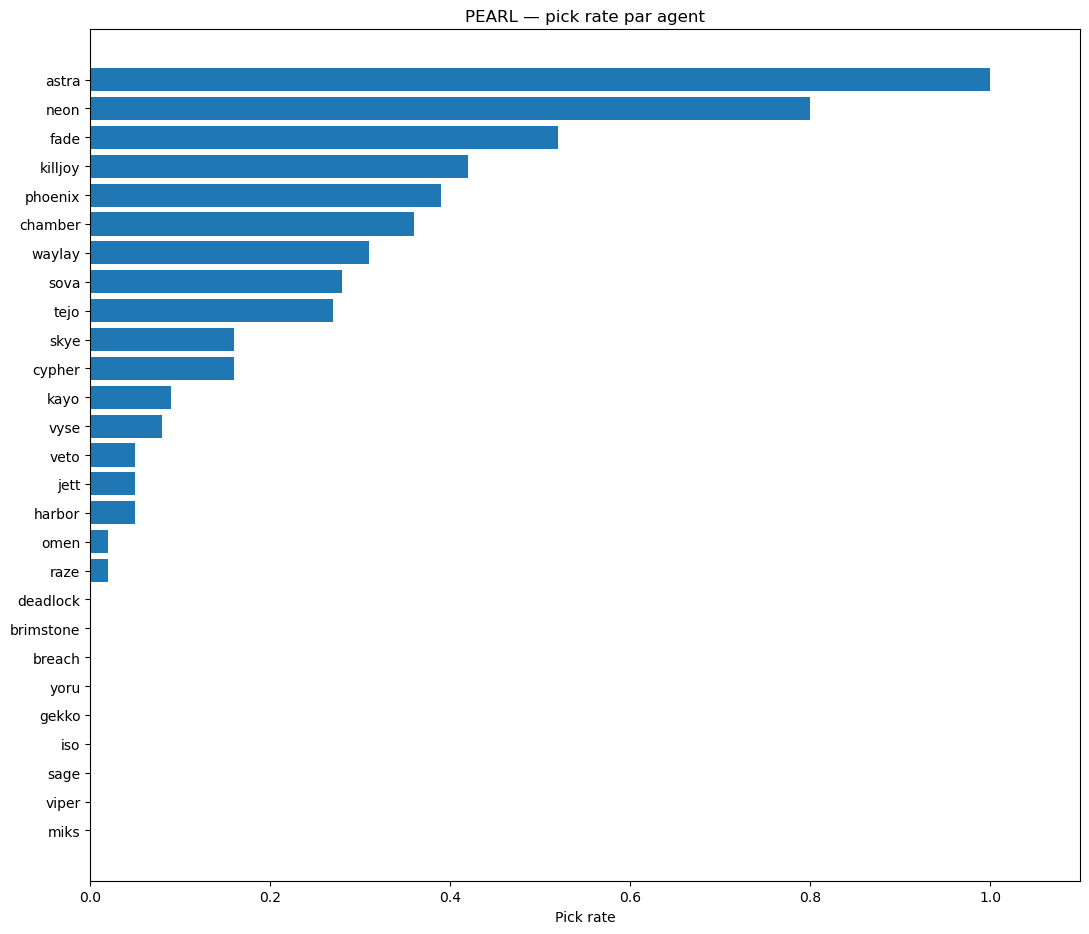

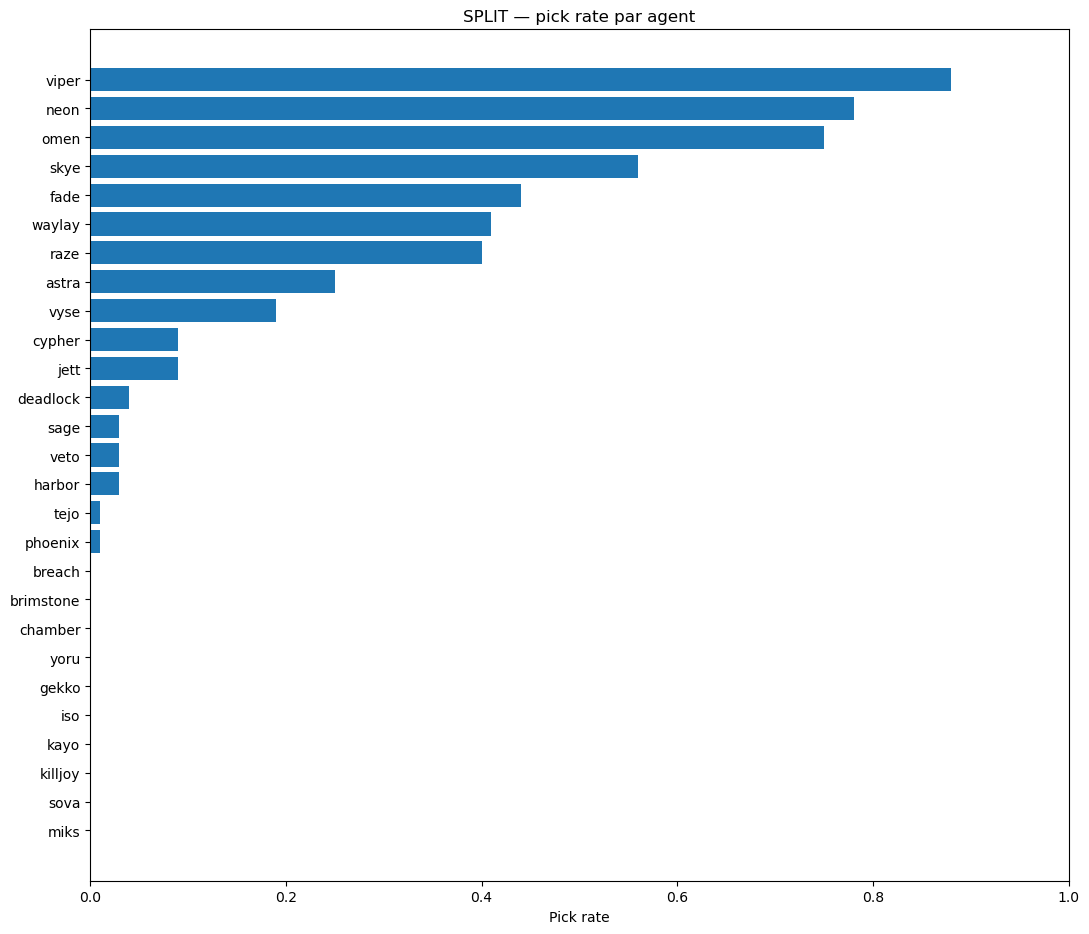

In [14]:
# ============================================================
# 5. Fonction de visualisation map-first
# ============================================================

def plot_map_profile(map_name: str, min_pick_rate: float = 0.0):
    data = full[full['map'].eq(map_name)].sort_values('pick_rate', ascending=True)
    if min_pick_rate > 0:
        data = data[data['pick_rate'].ge(min_pick_rate)]
    
    plt.figure(figsize=(11, max(5, 0.35 * len(data))))
    plt.barh(data['agent'], data['pick_rate'])
    plt.xlabel('Pick rate')
    plt.title(f'{map_name} — pick rate par agent')
    plt.xlim(0, max(1.0, data['pick_rate'].max() * 1.1 if len(data) else 1.0))
    plt.tight_layout()
    plt.show()

for map_name in maps:
    plot_map_profile(map_name)


In [24]:
# ============================================================
# 6. Tables top / absences / spécialistes par map
# ============================================================

MAP_TOP_N = 8
ABSENCE_THRESHOLD_GLOBAL = 0.20   # agent globalement assez joué
LOW_MAP_THRESHOLD = 0.05          # très peu joué sur une map
SPECIALIST_GAP = 0.20             # beaucoup plus joué sur cette map que globalement

map_tables = {}

for map_name in maps:
    d = full[full['map'].eq(map_name)].copy()
    
    top_map = d.sort_values('pick_rate', ascending=False).head(MAP_TOP_N)[
        ['map', 'agent', 'map_rank', 'pick_rate', 'global_pick_rate', 'pick_rate_gap_vs_global', 'agent_picks', 'map_total_compositions', 'map_pick_tier']
    ]
    
    absences = d[
        d['global_pick_rate'].ge(ABSENCE_THRESHOLD_GLOBAL) &
        d['pick_rate'].le(LOW_MAP_THRESHOLD)
    ].sort_values(['global_pick_rate', 'pick_rate_gap_vs_global'], ascending=[False, True])[
        ['map', 'agent', 'pick_rate', 'global_pick_rate', 'pick_rate_gap_vs_global', 'agent_picks', 'map_total_compositions']
    ]
    
    specialists = d[
        d['pick_rate_gap_vs_global'].ge(SPECIALIST_GAP)
    ].sort_values('pick_rate_gap_vs_global', ascending=False)[
        ['map', 'agent', 'pick_rate', 'global_pick_rate', 'pick_rate_gap_vs_global', 'agent_picks', 'map_total_compositions']
    ]
    
    map_tables[map_name] = {
        'top_map': top_map,
        'absences': absences,
        'specialists': specialists,
    }

for map_name, tables in map_tables.items():
    print('' + '=' * 100)
    print(f'MAP: {map_name}')
    print('=' * 100)
    print('Top agents de la map')
    display(tables['top_map'])
    print('Agents globalement joués mais absents/faibles sur cette map')
    display(tables['absences'] if len(tables['absences']) else pd.DataFrame({'info': ['Aucune absence forte détectée avec les seuils actuels.']}))
    print('Spécialistes ou sur-représentés sur cette map')
    display(tables['specialists'] if len(tables['specialists']) else pd.DataFrame({'info': ['Aucun spécialiste fort détecté avec les seuils actuels.']}))


MAP: BIND
Top agents de la map


,map,agent,map_rank,pick_rate,global_pick_rate,pick_rate_gap_vs_global,agent_picks,map_total_compositions,map_pick_tier
2,BIND,brimstone,1,0.93,0.23,0.70,56,60,core pick
23,BIND,viper,2,0.90,0.50,0.40,54,60,core pick
19,BIND,skye,2,0.90,0.34,0.56,54,60,core pick
14,BIND,neon,3,0.88,0.81,0.07,53,60,core pick
25,BIND,waylay,4,0.62,0.36,0.26,37,60,core pick
3,BIND,chamber,5,0.13,0.13,0.00,8,60,rare pick
17,BIND,raze,6,0.10,0.17,-0.07,6,60,rare pick
16,BIND,phoenix,7,0.08,0.15,-0.07,5,60,rare pick


Agents globalement joués mais absents/faibles sur cette map


,map,agent,pick_rate,global_pick_rate,pick_rate_gap_vs_global,agent_picks,map_total_compositions
15,BIND,omen,0.03,0.51,-0.48,2,60
20,BIND,sova,0.00,0.24,-0.24,0,60
4,BIND,cypher,0.02,0.23,-0.21,1,60


Spécialistes ou sur-représentés sur cette map


...

,map,agent,map_rank,pick_rate,global_pick_rate,pick_rate_gap_vs_global,agent_picks,map_total_compositions,map_pick_tier
185,SPLIT,viper,1,0.88,0.50,0.38,60,68,core pick
176,SPLIT,neon,2,0.78,0.81,-0.03,53,68,core pick
177,SPLIT,omen,3,0.75,0.51,0.24,51,68,core pick
181,SPLIT,skye,4,0.56,0.34,0.22,38,68,core pick
168,SPLIT,fade,5,0.44,0.36,0.08,30,68,strong pick
187,SPLIT,waylay,6,0.41,0.36,0.05,28,68,strong pick
179,SPLIT,raze,7,0.40,0.17,0.23,27,68,strong pick
162,SPLIT,astra,8,0.25,0.25,0.00,17,68,situational pick


Agents globalement joués mais absents/faibles sur cette map


,map,agent,pick_rate,global_pick_rate,pick_rate_gap_vs_global,agent_picks,map_total_compositions
182,SPLIT,sova,0.0,0.24,-0.24,0,68
164,SPLIT,brimstone,0.0,0.23,-0.23,0,68


Spécialistes ou sur-représentés sur cette map


,map,agent,pick_rate,global_pick_rate,pick_rate_gap_vs_global,agent_picks,map_total_compositions
185,SPLIT,viper,0.88,0.50,0.38,60,68
177,SPLIT,omen,0.75,0.51,0.24,51,68
179,SPLIT,raze,0.40,0.17,0.23,27,68
181,SPLIT,skye,0.56,0.34,0.22,38,68


## 6. Mesurer si une carte est fermée ou ouverte

Une map fermée signifie ici : quelques agents concentrent beaucoup de picks.  
Une map ouverte signifie : les picks sont plus distribués.

Indicateurs :

- `top_5_pick_share` : poids cumulé des 5 agents les plus joués ;
- `hhi` : concentration ; plus c'est haut, plus la map est standardisée ;
- `entropy` : diversité ; plus c'est haut, plus la map est ouverte ;
- `effective_agent_pool` : nombre approximatif d'agents réellement présents dans la méta.


,map,nb_agents_picked,nb_agents_not_picked,top_5_pick_share,hhi_concentration,entropy_diversity,effective_agent_pool,max_pick_rate,median_non_zero_pick_rate
0,BIND,20,7,4.23,0.147430,0.659906,6.782894,0.93,0.070
4,LOTUS,20,7,3.64,0.125904,0.701944,7.942559,1.00,0.100
6,SPLIT,17,10,3.41,0.116461,0.704913,8.586537,0.88,0.190
3,HAVEN,18,9,3.36,0.113263,0.733585,8.829002,0.93,0.180
2,FRACTURE,20,7,3.38,0.112898,0.730870,8.857521,0.89,0.110
1,BREEZE,16,11,3.28,0.112752,0.716140,8.869022,0.88,0.270
5,PEARL,18,9,3.13,0.106316,0.749638,9.405889,1.00,0.215


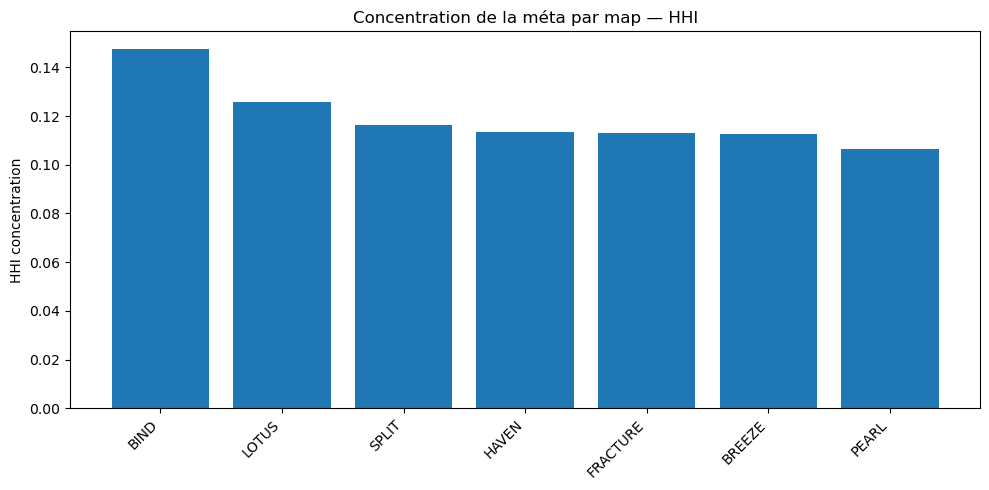

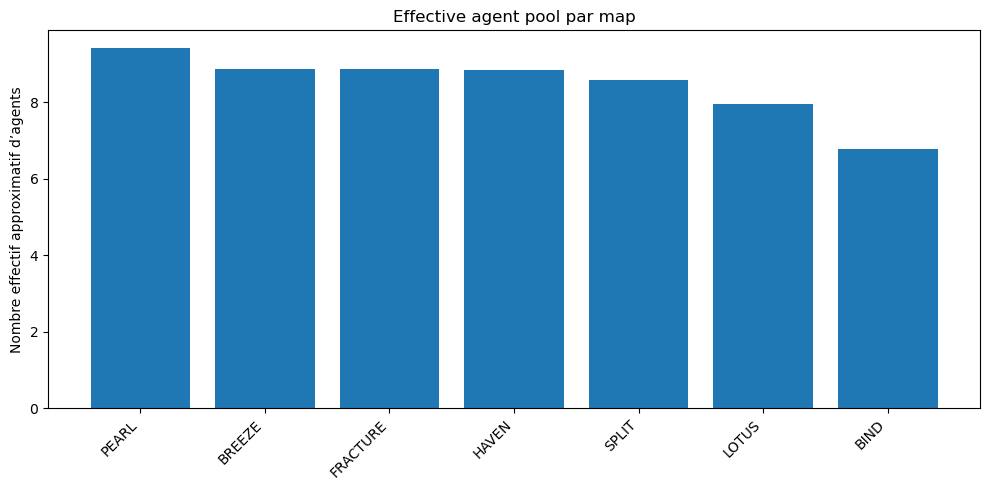

In [26]:
# ============================================================
# 7. Diversité / concentration par map
# ============================================================

def normalized_entropy(values):
    values = np.asarray(values, dtype=float)
    total = values.sum()
    if total <= 0:
        return 0
    p = values / total
    p = p[p > 0]
    if len(p) <= 1:
        return 0
    return float(-(p * np.log(p)).sum() / np.log(len(values)))

def hhi(values):
    values = np.asarray(values, dtype=float)
    total = values.sum()
    if total <= 0:
        return 0
    p = values / total
    return float((p ** 2).sum())

map_summary_rows = []
for map_name in maps:
    d = full[full['map'].eq(map_name)].copy()
    rates = d['pick_rate'].values
    non_zero = d[d['pick_rate'].gt(0)]
    top5_share = d.sort_values('pick_rate', ascending=False).head(5)['pick_rate'].sum()
    concentration = hhi(rates)
    entropy = normalized_entropy(rates)
    effective_pool = 1 / concentration if concentration > 0 else 0
    map_summary_rows.append({
        'map': map_name,
        'nb_agents_picked': int(non_zero['agent'].nunique()),
        'nb_agents_not_picked': int((d['pick_rate'].eq(0)).sum()),
        'top_5_pick_share': top5_share,
        'hhi_concentration': concentration,
        'entropy_diversity': entropy,
        'effective_agent_pool': effective_pool,
        'max_pick_rate': d['pick_rate'].max(),
        'median_non_zero_pick_rate': non_zero['pick_rate'].median() if len(non_zero) else 0,
    })

map_summary = pd.DataFrame(map_summary_rows).sort_values('hhi_concentration', ascending=False)
display(map_summary)

plt.figure(figsize=(10, 5))
plt.bar(map_summary['map'], map_summary['hhi_concentration'])
plt.title('Concentration de la méta par map — HHI')
plt.ylabel('HHI concentration')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(map_summary.sort_values('effective_agent_pool', ascending=False)['map'], map_summary.sort_values('effective_agent_pool', ascending=False)['effective_agent_pool'])
plt.title('Effective agent pool par map')
plt.ylabel('Nombre effectif approximatif d’agents')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 7. Spécialisation des agents

On cherche les agents qui ne sont pas forcément top 10 globaux mais qui ont une valeur contextuelle forte.


,agent,global_pick_rate,mean_map_pick_rate,max_map_pick_rate,std_map_pick_rate,maps_picked,zero_maps,best_map,best_map_pick_rate,specialization_score,best_map_gap_vs_global,agent_profile
2,brimstone,0.23,0.260000,0.93,0.444185,2,5,BIND,0.93,0.444185,0.70,map specialist
15,omen,0.51,0.442857,1.00,0.443235,7,0,LOTUS,1.00,0.443235,0.49,global core
23,viper,0.50,0.505714,0.90,0.404922,6,1,BIND,0.90,0.404922,0.40,global core
20,sova,0.24,0.261429,0.88,0.370424,3,4,BREEZE,0.88,0.370424,0.64,map specialist
0,astra,0.25,0.270000,1.00,0.348855,7,0,PEARL,1.00,0.348855,0.75,situational/flexible
6,fade,0.36,0.311429,0.88,0.316461,6,1,LOTUS,0.88,0.316461,0.52,global core
19,skye,0.34,0.351429,0.90,0.290427,7,0,BIND,0.90,0.290427,0.56,situational/flexible
4,cypher,0.23,0.230000,0.65,0.246847,7,0,FRACTURE,0.65,0.246847,0.42,situational/flexible
17,raze,0.17,0.158571,0.40,0.178179,5,2,LOTUS,0.40,0.178179,0.23,situational/flexible
10,jett,0.09,0.111429,0.50,0.177241,5,2,BREEZE,0.50,0.177241,0.41,hidden/niche specialist


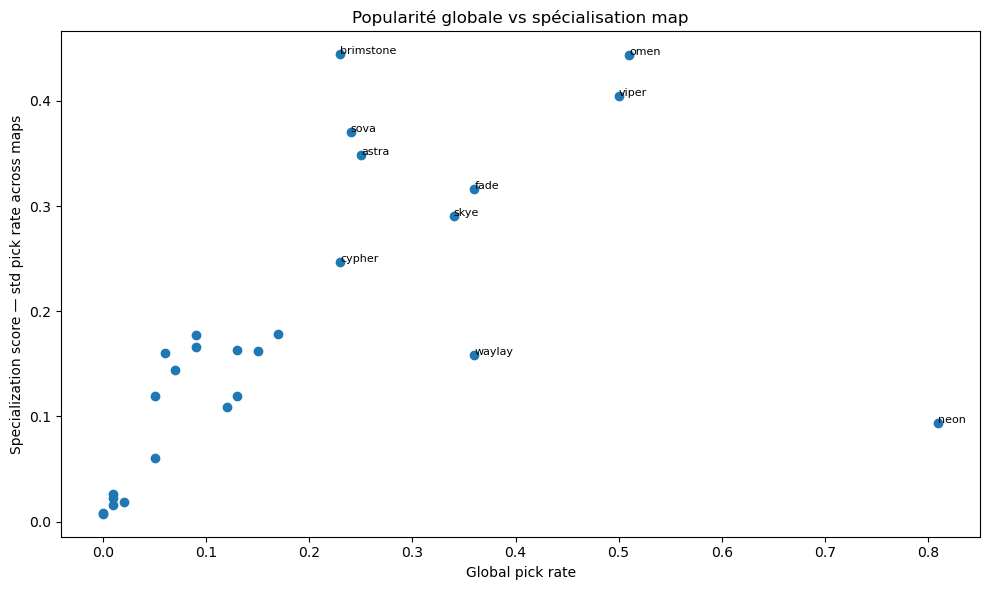

In [28]:
# ============================================================
# 8. Profil de spécialisation par agent
# ============================================================

agent_summary = (
    full.groupby('agent')
    .agg(
        global_pick_rate=('global_pick_rate', 'max'),
        mean_map_pick_rate=('pick_rate', 'mean'),
        max_map_pick_rate=('pick_rate', 'max'),
        std_map_pick_rate=('pick_rate', 'std'),
        maps_picked=('pick_rate', lambda s: int((s > 0).sum())),
        zero_maps=('pick_rate', lambda s: int((s == 0).sum())),
    )
    .reset_index()
)

best_map = full.loc[full.groupby('agent')['pick_rate'].idxmax(), ['agent', 'map', 'pick_rate']].rename(columns={'map': 'best_map', 'pick_rate': 'best_map_pick_rate'})
agent_summary = agent_summary.merge(best_map, on='agent', how='left')
agent_summary['specialization_score'] = agent_summary['std_map_pick_rate'].fillna(0)
agent_summary['best_map_gap_vs_global'] = agent_summary['best_map_pick_rate'] - agent_summary['global_pick_rate']

# Classification orientée analyse, pas vérité absolue
agent_summary['agent_profile'] = np.select(
    [
        (agent_summary['global_pick_rate'] >= 0.35) & (agent_summary['zero_maps'] <= 1),
        (agent_summary['best_map_gap_vs_global'] >= 0.25) & (agent_summary['maps_picked'] <= 4),
        (agent_summary['global_pick_rate'] < 0.15) & (agent_summary['best_map_pick_rate'] >= 0.25),
        (agent_summary['global_pick_rate'] < 0.10) & (agent_summary['best_map_pick_rate'] < 0.15),
    ],
    ['global core', 'map specialist', 'hidden/niche specialist', 'low presence'],
    default='situational/flexible'
)

agent_summary = agent_summary.sort_values(['specialization_score', 'best_map_pick_rate'], ascending=False)
display(agent_summary)

plt.figure(figsize=(10, 6))
plt.scatter(agent_summary['global_pick_rate'], agent_summary['specialization_score'])
for _, row in agent_summary.iterrows():
    if row['specialization_score'] >= agent_summary['specialization_score'].quantile(0.70) or row['global_pick_rate'] >= 0.30:
        plt.text(row['global_pick_rate'], row['specialization_score'], row['agent'], fontsize=8)
plt.xlabel('Global pick rate')
plt.ylabel('Specialization score — std pick rate across maps')
plt.title('Popularité globale vs spécialisation map')
plt.tight_layout()
plt.show()


## 8. Détection des absences intéressantes

Une absence intéressante n'est pas simplement un agent à 0 %.  
C'est plutôt : un agent globalement joué, mais très peu ou pas joué sur une map précise.


,map,agent,pick_rate,global_pick_rate,absence_score,agent_picks,map_total_compositions
158,PEARL,viper,0.00,0.50,0.50,0,64
69,FRACTURE,omen,0.02,0.51,0.49,1,54
150,PEARL,omen,0.02,0.51,0.49,1,64
77,FRACTURE,viper,0.02,0.50,0.48,1,54
15,BIND,omen,0.03,0.51,0.48,2,60
33,BREEZE,fade,0.00,0.36,0.36,0,48
182,SPLIT,sova,0.00,0.24,0.24,0,68
20,BIND,sova,0.00,0.24,0.24,0,60
74,FRACTURE,sova,0.00,0.24,0.24,0,54
108,LOTUS,astra,0.01,0.25,0.24,1,90


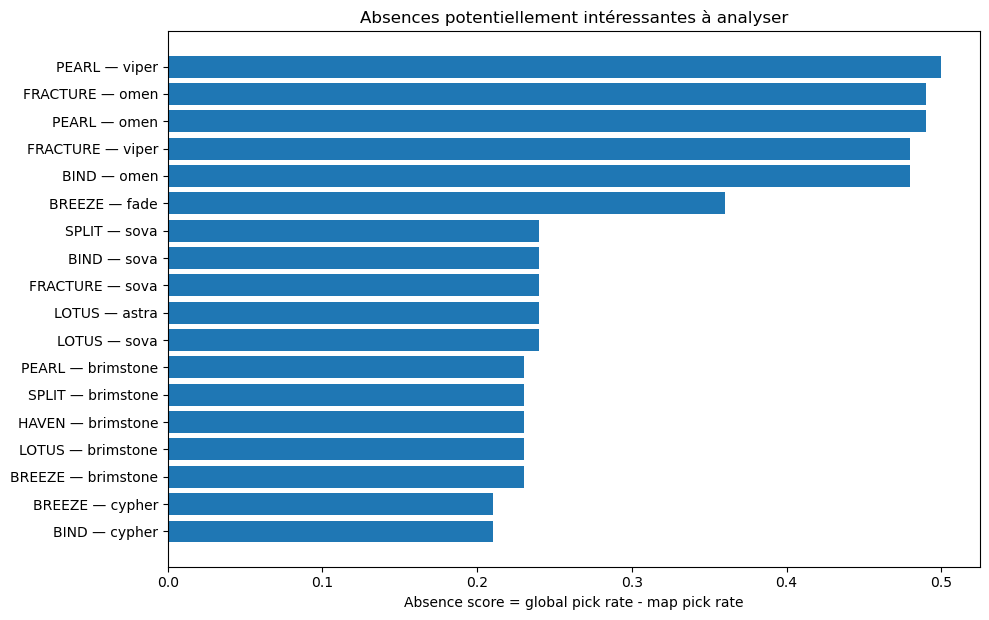

In [30]:
# ============================================================
# 9. Ranking des absences anormales
# ============================================================

absence_candidates = full[
    (full['global_pick_rate'] >= ABSENCE_THRESHOLD_GLOBAL) &
    (full['pick_rate'] <= LOW_MAP_THRESHOLD)
].copy()

absence_candidates['absence_score'] = absence_candidates['global_pick_rate'] - absence_candidates['pick_rate']
absence_candidates = absence_candidates.sort_values('absence_score', ascending=False)

display(absence_candidates[[
    'map', 'agent', 'pick_rate', 'global_pick_rate', 'absence_score', 'agent_picks', 'map_total_compositions'
]])

plt.figure(figsize=(10, max(5, 0.35 * len(absence_candidates))))
labels = absence_candidates['map'] + ' — ' + absence_candidates['agent']
plt.barh(labels[::-1], absence_candidates['absence_score'][::-1])
plt.xlabel('Absence score = global pick rate - map pick rate')
plt.title('Absences potentiellement intéressantes à analyser')
plt.tight_layout()
plt.show()


## 9. Génération automatique d'insights par map

Ces textes doivent être lus comme des **remarques analytiques**, pas comme des preuves définitives.  
Le but est d'aider à prioriser l'analyse humaine.


In [34]:
# ============================================================
# 10. Génération d'insights automatiques
# ============================================================

def format_pct(x):
    return f'{x:.0%}'


def generate_map_insights(map_name: str) -> list[str]:
    d = full[full['map'].eq(map_name)].copy().sort_values('pick_rate', ascending=False)
    summary = map_summary[map_summary['map'].eq(map_name)].iloc[0]
    insights = []
    
    top = d.head(5)
    top_agents = ', '.join([f"{r.agent} ({format_pct(r.pick_rate)})" for r in top.itertuples()])
    insights.append(f"Top structurel de {map_name}: {top_agents}.")
    
    if summary['hhi_concentration'] >= map_summary['hhi_concentration'].quantile(0.75):
        insights.append(
            f"{map_name} semble être une map assez standardisée: HHI élevé ({summary['hhi_concentration']:.3f}) "
            f"et top 5 cumulé à {summary['top_5_pick_share']:.2f}."
        )
    elif summary['entropy_diversity'] >= map_summary['entropy_diversity'].quantile(0.75):
        insights.append(
            f"{map_name} paraît plus ouverte que les autres: diversité élevée ({summary['entropy_diversity']:.3f}) "
            f"et {int(summary['nb_agents_picked'])} agents observés."
        )
    else:
        insights.append(
            f"{map_name} a une diversité intermédiaire: {int(summary['nb_agents_picked'])} agents joués, "
            f"{int(summary['nb_agents_not_picked'])} non joués."
        )
    
    specialists = d[d['pick_rate_gap_vs_global'] >= SPECIALIST_GAP].sort_values('pick_rate_gap_vs_global', ascending=False).head(5)
    if len(specialists):
        spec_txt = ', '.join([f"{r.agent} (+{format_pct(r.pick_rate_gap_vs_global)} vs global)" for r in specialists.itertuples()])
        insights.append(f"Agents sur-représentés sur cette map: {spec_txt}. Cela suggère une valeur contextuelle spécifique à la carte.")
    
    absences = d[(d['global_pick_rate'] >= ABSENCE_THRESHOLD_GLOBAL) & (d['pick_rate'] <= LOW_MAP_THRESHOLD)].sort_values('global_pick_rate', ascending=False).head(5)
    if len(absences):
        abs_txt = ', '.join([f"{r.agent} ({format_pct(r.global_pick_rate)} global → {format_pct(r.pick_rate)} ici)" for r in absences.itertuples()])
        insights.append(f"Absences/faiblesses notables: {abs_txt}. À analyser côté layout, rôle déjà couvert ou incompatibilité de composition.")
    
    rare_but_present = d[(d['pick_rate'] > 0) & (d['pick_rate'] < 0.15)].sort_values('pick_rate', ascending=False).head(5)
    if len(rare_but_present):
        rare_txt = ', '.join([f"{r.agent} ({format_pct(r.pick_rate)})" for r in rare_but_present.itertuples()])
        insights.append(f"Picks rares mais présents: {rare_txt}. Potentiels choix de niche, anti-meta ou adaptation d'équipe.")
    
    return insights

for map_name in maps:
    print('' + '=' * 100)
    print(f'INSIGHTS — {map_name}')
    print('=' * 100)
    for insight in generate_map_insights(map_name):
        print('• ' + insight)


INSIGHTS — BIND
• Top structurel de BIND: brimstone (93%), viper (90%), skye (90%), neon (88%), waylay (62%).
• BIND semble être une map assez standardisée: HHI élevé (0.147) et top 5 cumulé à 4.23.
• Agents sur-représentés sur cette map: brimstone (+70% vs global), skye (+56% vs global), viper (+40% vs global), waylay (+26% vs global). Cela suggère une valeur contextuelle spécifique à la carte.
• Absences/faiblesses notables: omen (51% global → 3% ici), sova (24% global → 0% ici), cypher (23% global → 2% ici). À analyser côté layout, rôle déjà couvert ou incompatibilité de composition.
• Picks rares mais présents: chamber (13%), raze (10%), phoenix (8%), astra (7%), fade (7%). Potentiels choix de niche, anti-meta ou adaptation d'équipe.
INSIGHTS — BREEZE
• Top structurel de BREEZE: sova (88%), viper (88%), neon (62%), jett (50%), astra (40%).
• BREEZE a une diversité intermédiaire: 16 agents joués, 11 non joués.
• Agents sur-représentés sur cette map: sova (+64% vs global), jett (+41%

## 10. Export des tables utiles

Ces fichiers peuvent ensuite alimenter ton dashboard React/Streamlit.


In [ ]:
# ============================================================
# 11. Exports
# ============================================================

OUTPUT_DIR = Path('outputs_map_first_analysis')
OUTPUT_DIR.mkdir(exist_ok=True)

full.to_csv(OUTPUT_DIR / 'agent_map_full_matrix.csv', index=False)
map_summary.to_csv(OUTPUT_DIR / 'map_meta_diversity_summary.csv', index=False)
agent_summary.to_csv(OUTPUT_DIR / 'agent_specialization_summary.csv', index=False)
absence_candidates.to_csv(OUTPUT_DIR / 'map_absence_candidates.csv', index=False)

print(f'Exports générés dans : {OUTPUT_DIR.resolve()}')


## 11. Lecture correcte des résultats

Ce notebook répond mieux à ton problème parce qu'il sépare :

1. **popularité globale** : qui est beaucoup joué dans l'ensemble ;
2. **valeur par map** : qui structure une carte précise ;
3. **spécialisation** : qui dépend fortement du contexte ;
4. **absence anormale** : qui est globalement joué mais disparaît sur une map ;
5. **diversité de map** : est-ce que la carte impose une méta fermée ou permet plusieurs approches ?

La suite logique serait d'ajouter les compositions complètes par équipe/map, car l'agent seul ne suffit pas : beaucoup de picks n'ont de sens qu'en synergie avec 4 autres agents.


In [42]:
import pandas as pd
from pathlib import Path

# =========================
# CONFIG
# =========================

INPUT_CSV = Path("data/processed/vlr_agents_matrix_aggregated.csv")
OUTPUT_EXCEL = Path("data/processed/valorant_agents_peak_probabilities.xlsx")

# =========================
# LOAD DATA
# =========================

df = pd.read_csv(INPUT_CSV)

# Nettoyage basique des noms de colonnes
df.columns = [col.strip().lower() for col in df.columns]

print(df.columns.tolist())
df.head()

['map', 'agent', 'agent_picks', 'total_compositions', 'pick_rate']


,map,agent,agent_picks,total_compositions,pick_rate
0,All Maps,neon,372,460,0.81
1,All Maps,omen,233,460,0.51
2,All Maps,viper,230,460,0.50
3,All Maps,fade,164,460,0.36
4,All Maps,waylay,167,460,0.36


In [44]:
# =========================
# AUTO-DETECT COLUMNS
# =========================

agent_col = next(col for col in df.columns if "agent" in col)
map_col = next(col for col in df.columns if "map" in col)
pick_col = next(col for col in df.columns if "pick" in col)

agent_col, map_col, pick_col

('agent', 'map', 'agent_picks')

In [46]:
# =========================
# FUNCTION
# =========================

def build_pick_probability_table(data: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule la probabilité qu'un agent soit pick dans un contexte donné.
    
    Formule :
    agent_pick_probability = agent_pick_value / total_pick_value
    """
    
    grouped = (
        data.groupby(agent_col, as_index=False)[pick_col]
        .sum()
        .rename(columns={pick_col: "pick_value"})
    )
    
    total_pick = grouped["pick_value"].sum()
    
    if total_pick == 0:
        grouped["pick_probability"] = 0
    else:
        grouped["pick_probability"] = grouped["pick_value"] / total_pick
    
    grouped["pick_probability_percent"] = grouped["pick_probability"] * 100
    
    grouped = grouped.sort_values(
        by="pick_probability",
        ascending=False
    ).reset_index(drop=True)
    
    grouped["rank"] = grouped.index + 1
    
    return grouped[
        [
            "rank",
            agent_col,
            "pick_value",
            "pick_probability",
            "pick_probability_percent",
        ]
    ]

In [48]:
# =========================
# EXPORT EXCEL
# =========================

maps = sorted(df[map_col].dropna().unique())

with pd.ExcelWriter(OUTPUT_EXCEL, engine="openpyxl") as writer:
    
    # Feuille globale
    all_maps_table = build_pick_probability_table(df)
    all_maps_table.to_excel(
        writer,
        sheet_name="ALL_MAPS",
        index=False
    )
    
    # Une feuille par map
    for map_name in maps:
        map_data = df[df[map_col] == map_name].copy()
        map_table = build_pick_probability_table(map_data)
        
        # Excel limite les noms de feuilles à 31 caractères
        sheet_name = str(map_name)[:31]
        
        map_table.to_excel(
            writer,
            sheet_name=sheet_name,
            index=False
        )

print(f"Excel généré : {OUTPUT_EXCEL.resolve()}")

Excel généré : C:\Users\emman\Downloads\scrap vlr\data\processed\valorant_agents_peak_probabilities.xlsx
